# Business Data Statistical Analysis
### Datasets: `customer_churn.xlsx` and `sales_data.xlsx`

Covers:
1. Comprehensive descriptive statistics
2. Distribution analysis (histograms & density plots)
3. T-tests to compare groups
4. Correlation between business metrics
5. P-value interpretation in business context
6. Confidence intervals for key metrics

**Works in both VS Code (Jupyter extension) and Google Colab.** See the **Load Data** cell for the one-line change each environment needs.

## 0. Setup

In [2]:
import sys, subprocess
required = ["pandas", "numpy", "matplotlib", "seaborn", "scipy", "openpyxl"]
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("Setup complete.")


Setup complete.


To install other libraries, you can either add them to the `required` list in the setup cell above, or run `!pip install your_package_name` in a new code cell.

For example, to install `requests`:
```python
!pip install requests
```

## 1. Load Data

- **VS Code**: put `customer_churn.xlsx` and `sales_data.xlsx` in the same folder as this notebook — the default paths below already work.
- **Google Colab**: uncomment the upload snippet in the cell below, run it, and select both files when prompted.


In [5]:
# ---- Google Colab only: uncomment to upload the two files ----
from google.colab import files
uploaded = files.upload()   # select customer_churn.xlsx and sales_data.xlsx

churn = pd.read_excel("customer_churn.xlsx")
sales = pd.read_excel("sales_data.xlsx")

print(f"customer_churn.xlsx: {churn.shape[0]} rows, {churn.shape[1]} columns")
print(f"sales_data.xlsx:     {sales.shape[0]} rows, {sales.shape[1]} columns")

churn["ChurnLabel"] = churn["Churn"].map({0: "Retained", 1: "Churned"})
churn.head()

Saving sales_data.xlsx to sales_data.xlsx
customer_churn.xlsx: 500 rows, 9 columns
sales_data.xlsx:     100 rows, 7 columns


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,ChurnLabel
0,C00001,6,64,1540,One year,Credit Card,No,1,0,Retained
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,Retained
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,Retained
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0,Retained
4,C00005,16,185,1023,One year,Electronic Check,No,1,0,Retained


In [6]:
sales.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


## 2. Comprehensive Descriptive Statistics

In [7]:
def comprehensive_stats(dataframe, numeric_cols):
    rows = []
    for col in numeric_cols:
        s = dataframe[col].dropna()
        rows.append({
            "metric": col,
            "count": s.count(),
            "mean": s.mean(),
            "median": s.median(),
            "std_dev": s.std(),
            "variance": s.var(),
            "min": s.min(),
            "max": s.max(),
            "range": s.max() - s.min(),
            "q1_25%": s.quantile(0.25),
            "q3_75%": s.quantile(0.75),
            "iqr": s.quantile(0.75) - s.quantile(0.25),
            "skewness": s.skew(),
            "kurtosis": s.kurt(),
            "coef_of_variation_%": (s.std() / s.mean()) * 100 if s.mean() != 0 else np.nan,
        })
    return pd.DataFrame(rows).set_index("metric")

churn_numeric = ["Tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
sales_numeric = ["Quantity", "Price", "Total_Sales"]

print("=== Customer Churn: Descriptive Statistics ===")
churn_stats = comprehensive_stats(churn, churn_numeric)
display(churn_stats)

print("\n=== Sales Data: Descriptive Statistics ===")
sales_stats = comprehensive_stats(sales, sales_numeric)
display(sales_stats)

=== Customer Churn: Descriptive Statistics ===


,count,mean,median,std_dev,variance,min,max,range,q1_25%,q3_75%,iqr,skewness,kurtosis,coef_of_variation_%
metric,,,,,,,,,,,,,,
Tenure,500,36.53,37.00,20.67,427.13,1,71,70,19.00,54.00,35.00,-0.09,-1.22,56.57
MonthlyCharges,500,113.64,115.00,51.80,"2,683.23",20,199,179,67.00,158.00,91.00,-0.09,-1.21,45.58
TotalCharges,500,"4,237.88","4,182.50","2,260.62","5,110,402.05",159,7992,7833,"2,237.25","6,266.75","4,029.50",-0.03,-1.22,53.34
SeniorCitizen,500,0.50,0.00,0.50,0.25,0,1,1,0.00,1.00,1.00,0.01,-2.01,100.50



=== Sales Data: Descriptive Statistics ===


,count,mean,median,std_dev,variance,min,max,range,q1_25%,q3_75%,iqr,skewness,kurtosis,coef_of_variation_%
metric,,,,,,,,,,,,,,
Quantity,100,4.78,5.00,2.59,6.70,1,9,8,2.75,7.00,4.25,0.07,-1.20,54.15
Price,100,"25,808.51","24,192.00","13,917.63","193,700,431.55",1308,49930,48622,"14,965.25","38,682.25","23,717.00",-0.01,-1.26,53.93
Total_Sales,100,"123,650.48","97,955.50","100,161.09","10,032,243,003.46",6540,373932,367392,"39,517.50","175,792.50","136,275.00",0.88,-0.18,81.00


In [9]:
# Overall churn rate and category breakdowns
print(f"Overall churn rate: {churn['Churn'].mean()*100:.2f}%\n")
print("Churn rate by Contract type:")
print((churn.groupby("Contract")["Churn"].mean() * 100).round(2).astype(str) + "%")
print("\nChurn rate by Payment Method:")
print((churn.groupby("PaymentMethod")["Churn"].mean() * 100).round(2).astype(str) + "%")
print("\nTotal sales by Region:")
print(sales.groupby("Region")["Total_Sales"].sum().sort_values(ascending=False))
print("\nTotal sales by Product:")
print(sales.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False))


Overall churn rate: 10.60%

Churn rate by Contract type:
Contract
Month-to-month    20.59%
One year            4.3%
Two year           6.94%
Name: Churn, dtype: object

Churn rate by Payment Method:
PaymentMethod
Bank Transfer        6.92%
Credit Card         13.48%
Electronic Check    11.04%
Name: Churn, dtype: object

Total sales by Region:
Region
North    3983635
South    3737852
East     2519639
West     2123922
Name: Total_Sales, dtype: int64

Total sales by Product:
Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64


**Reading the table:** Skewness > 0 means a long right tail of high-value outliers. Kurtosis > 0 means heavier tails than a normal distribution (more extreme values than expected).

## 3. Distribution Analysis: Histograms & Density Plots


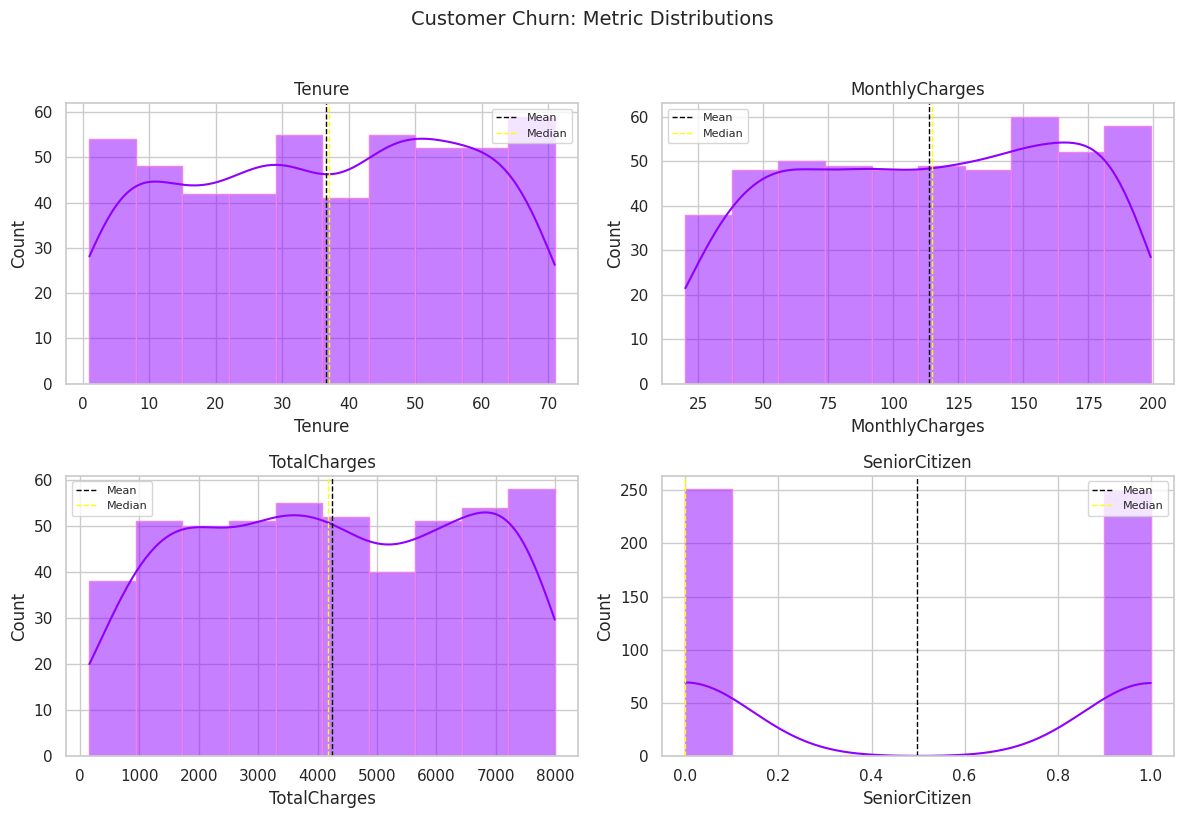

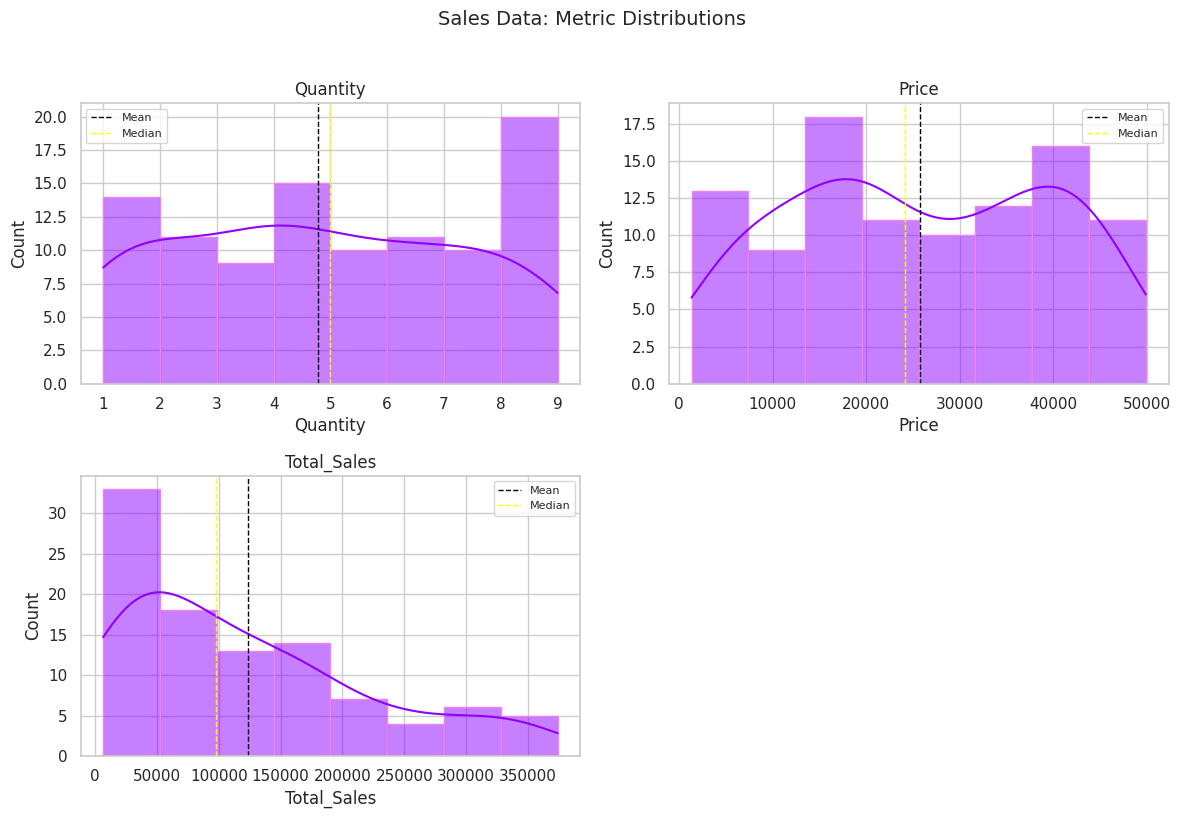

In [13]:
def plot_distributions(dataframe, cols, title):
    n_cols = 2
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(cols):
        ax = axes[i]
        sns.histplot(dataframe[col], kde=True, ax=ax, color="#8F00FF", edgecolor="violet")
        ax.axvline(dataframe[col].mean(), color="black", linestyle="--", linewidth=1, label="Mean")
        ax.axvline(dataframe[col].median(), color="yellow", linestyle="--", linewidth=1, label="Median")
        ax.set_title(col)
        ax.legend(fontsize=8)
    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_distributions(churn, churn_numeric, "Customer Churn: Metric Distributions")
plot_distributions(sales, sales_numeric, "Sales Data: Metric Distributions")

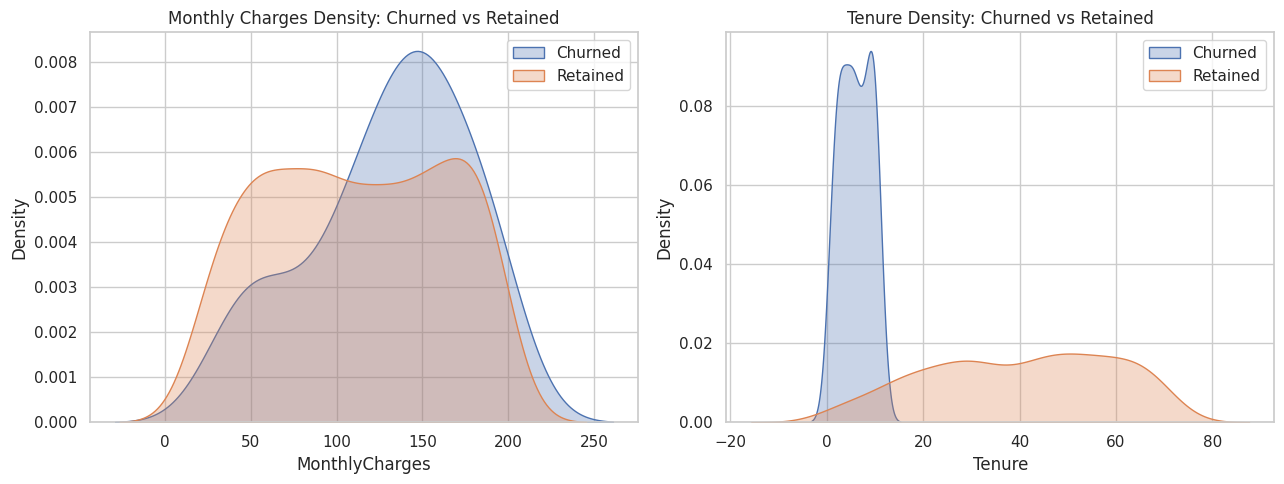

In [14]:
# Density comparison: does the distribution shift for churned vs retained customers?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, group_df in churn.groupby("ChurnLabel"):
    sns.kdeplot(group_df["MonthlyCharges"], label=label, fill=True, alpha=0.3, ax=axes[0])
    sns.kdeplot(group_df["Tenure"], label=label, fill=True, alpha=0.3, ax=axes[1])
axes[0].set_title("Monthly Charges Density: Churned vs Retained")
axes[1].set_title("Tenure Density: Churned vs Retained")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()

## 4. T-Tests to Compare Groups

An independent-samples t-test tells us whether a difference in means between two groups is likely real, or just sampling noise.

In [15]:
def run_ttest(dataframe, metric, group_col, group1, group2, alpha=0.05):
    g1 = dataframe.loc[dataframe[group_col] == group1, metric].dropna()
    g2 = dataframe.loc[dataframe[group_col] == group2, metric].dropna()

    _, levene_p = stats.levene(g1, g2)
    equal_var = levene_p > 0.05
    t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=equal_var)

    pooled_std = np.sqrt(((g1.std() ** 2) + (g2.std() ** 2)) / 2)
    cohens_d = (g1.mean() - g2.mean()) / pooled_std

    return {
        "metric": metric,
        "group1": f"{group1} (n={len(g1)}, mean={g1.mean():.2f})",
        "group2": f"{group2} (n={len(g2)}, mean={g2.mean():.2f})",
        "mean_difference": g1.mean() - g2.mean(),
        "t_statistic": t_stat,
        "p_value": p_value,
        "equal_variances_assumed": equal_var,
        "cohens_d": cohens_d,
        "significant_at_0.05": p_value < alpha,
    }

# Does Monthly Charges differ between churned and retained customers?
result_charges = run_ttest(churn, "MonthlyCharges", "ChurnLabel", "Churned", "Retained")
# Does Tenure differ between churned and retained customers?
result_tenure = run_ttest(churn, "Tenure", "ChurnLabel", "Churned", "Retained")

for label, result in [("MonthlyCharges: Churned vs Retained", result_charges),
                       ("Tenure: Churned vs Retained", result_tenure)]:
    print(f"--- {label} ---")
    for k, v in result.items():
        print(f"  {k:26s}: {v}")
    print()

--- MonthlyCharges: Churned vs Retained ---
  metric                    : MonthlyCharges
  group1                    : Churned (n=53, mean=129.77)
  group2                    : Retained (n=447, mean=111.72)
  mean_difference           : 18.05098982736061
  t_statistic               : 2.646439327283195
  p_value                   : 0.010079197699533079
  equal_variances_assumed   : False
  cohens_d                  : 0.36614079880940714
  significant_at_0.05       : True

--- Tenure: Churned vs Retained ---
  metric                    : Tenure
  group1                    : Churned (n=53, mean=6.00)
  group2                    : Retained (n=447, mean=40.15)
  mean_difference           : -34.15212527964206
  t_statistic               : -34.53490213270181
  p_value                   : 8.982326405691704e-130
  equal_variances_assumed   : False
  cohens_d                  : -2.535684766340613
  significant_at_0.05       : True



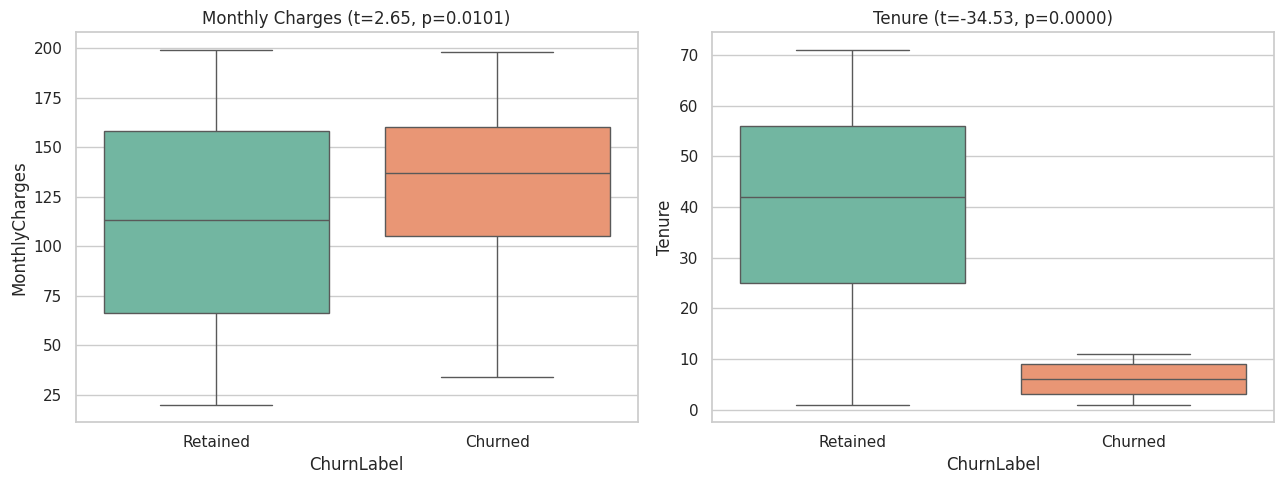

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=churn, x="ChurnLabel", y="MonthlyCharges", hue="ChurnLabel", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title(f"Monthly Charges (t={result_charges['t_statistic']:.2f}, p={result_charges['p_value']:.4f})")
sns.boxplot(data=churn, x="ChurnLabel", y="Tenure", hue="ChurnLabel", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title(f"Tenure (t={result_tenure['t_statistic']:.2f}, p={result_tenure['p_value']:.4f})")
plt.tight_layout()
plt.show()

In [17]:
# Sales example: compare Total_Sales between the two highest-selling regions
region_totals = sales.groupby("Region")["Total_Sales"].sum().sort_values(ascending=False)
top_region, second_region = region_totals.index[0], region_totals.index[1]

result_region = run_ttest(sales, "Total_Sales", "Region", top_region, second_region)
print(f"--- Total_Sales: {top_region} vs {second_region} ---")
for k, v in result_region.items():
    print(f"  {k:26s}: {v}")

--- Total_Sales: North vs South ---
  metric                    : Total_Sales
  group1                    : North (n=28, mean=142272.68)
  group2                    : South (n=27, mean=138438.96)
  mean_difference           : 3833.715608465631
  t_statistic               : 0.1303316283399723
  p_value                   : 0.8967974805172008
  equal_variances_assumed   : True
  cohens_d                  : 0.035095459555309204
  significant_at_0.05       : False


**Cohen's d rule of thumb:** 0.2 = small, 0.5 = medium, 0.8+ = large effect. A statistically significant p-value with a small effect size may not be worth acting on operationally.

## 5. Correlation Between Business Metrics

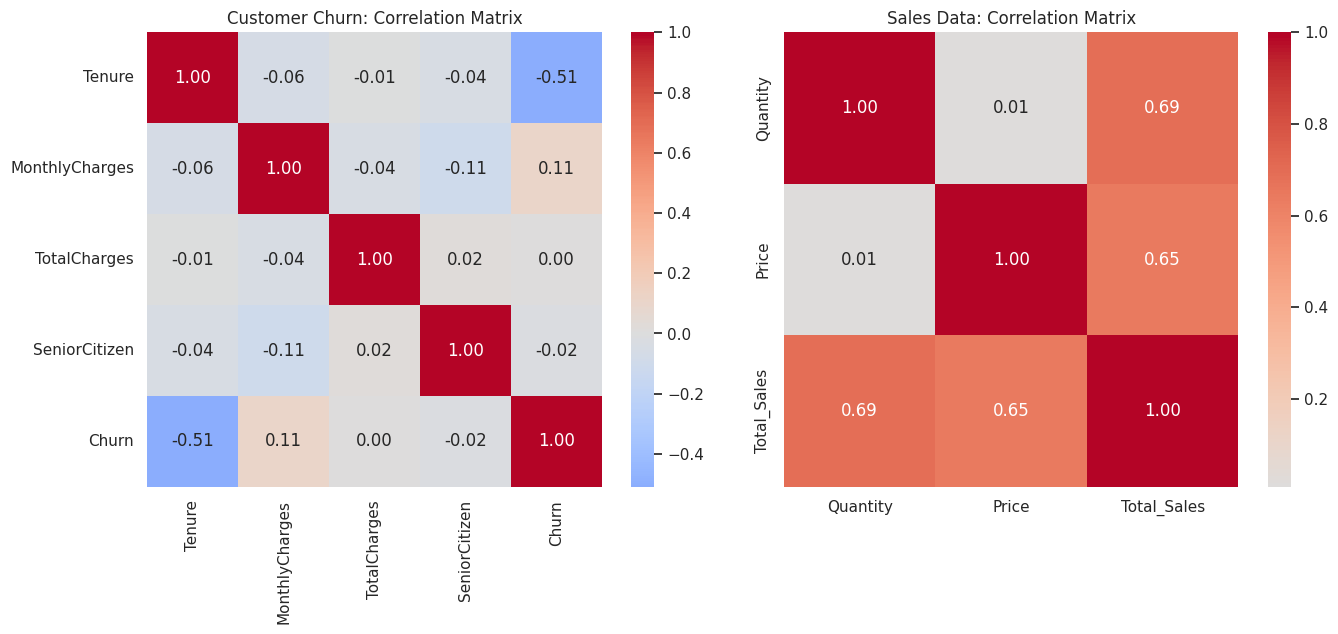

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

churn_corr = churn[churn_numeric + ["Churn"]].corr(method="pearson")
sns.heatmap(churn_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=axes[0])
axes[0].set_title("Customer Churn: Correlation Matrix")

sales_corr = sales[sales_numeric].corr(method="pearson")
sns.heatmap(sales_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=axes[1])
axes[1].set_title("Sales Data: Correlation Matrix")

plt.tight_layout()
plt.show()

In [19]:
def correlation_with_pvalue(dataframe, col1, col2):
    valid = dataframe[[col1, col2]].dropna()
    r, p = stats.pearsonr(valid[col1], valid[col2])
    return r, p

pairs = [
    ("Tenure", "TotalCharges"),
    ("MonthlyCharges", "TotalCharges"),
    ("Tenure", "Churn"),
    ("MonthlyCharges", "Churn"),
]
print("=== Customer Churn correlations ===")
for c1, c2 in pairs:
    r, p = correlation_with_pvalue(churn, c1, c2)
    strength = "strong" if abs(r) >= 0.7 else "moderate" if abs(r) >= 0.4 else "weak"
    print(f"{c1:16s} vs {c2:16s}  r = {r:6.3f}  p = {p:.4f}  ({strength}, "
          f"{'significant' if p < 0.05 else 'not significant'})")

print("\n=== Sales Data correlations ===")
for c1, c2 in [("Quantity", "Total_Sales"), ("Price", "Total_Sales"), ("Quantity", "Price")]:
    r, p = correlation_with_pvalue(sales, c1, c2)
    strength = "strong" if abs(r) >= 0.7 else "moderate" if abs(r) >= 0.4 else "weak"
    print(f"{c1:16s} vs {c2:16s}  r = {r:6.3f}  p = {p:.4f}  ({strength}, "
          f"{'significant' if p < 0.05 else 'not significant'})")

=== Customer Churn correlations ===
Tenure           vs TotalCharges      r = -0.006  p = 0.8992  (weak, not significant)
MonthlyCharges   vs TotalCharges      r = -0.042  p = 0.3454  (weak, not significant)
Tenure           vs Churn             r = -0.509  p = 0.0000  (moderate, significant)
MonthlyCharges   vs Churn             r =  0.107  p = 0.0163  (weak, significant)

=== Sales Data correlations ===
Quantity         vs Total_Sales       r =  0.688  p = 0.0000  (moderate, significant)
Price            vs Total_Sales       r =  0.646  p = 0.0000  (moderate, significant)
Quantity         vs Price             r =  0.008  p = 0.9369  (weak, not significant)


## 6. Interpreting P-Values in Business Context

A p-value is **the probability of seeing a difference this large (or larger) if there were truly no effect.** It is NOT the probability your hypothesis is true, and NOT the probability the result is due to chance.

- **p < 0.01** — very strong evidence of a real effect
- **p < 0.05** — standard evidence threshold (95% confidence)
- **p < 0.10** — weak/suggestive, worth a follow-up test
- **p >= 0.10** — no reliable evidence of an effect in this data

In [20]:
def interpret_pvalue(p_value, context="", alpha=0.05):
    if p_value < 0.01:
        strength = "very strong"
    elif p_value < 0.05:
        strength = "strong"
    elif p_value < 0.10:
        strength = "weak / suggestive"
    else:
        strength = "insufficient"
    decision = "statistically significant" if p_value < alpha else "not statistically significant"
    business_read = (
        "There is likely a real effect here — worth acting on, but confirm the effect size "
        "(e.g. Cohen's d) is large enough to matter operationally."
        if p_value < alpha else
        "The observed difference could plausibly be random noise. Avoid a costly decision "
        "based on this alone; consider a larger sample."
    )
    return (f"[{context}] p = {p_value:.4f} -> {decision} at alpha={alpha}.\n"
            f"  Evidence strength: {strength}.\n  Business read: {business_read}")

print(interpret_pvalue(result_charges["p_value"], "MonthlyCharges: Churned vs Retained"))
print()
print(interpret_pvalue(result_tenure["p_value"], "Tenure: Churned vs Retained"))
print()
print(interpret_pvalue(result_region["p_value"], f"Total_Sales: {top_region} vs {second_region}"))

[MonthlyCharges: Churned vs Retained] p = 0.0101 -> statistically significant at alpha=0.05.
  Evidence strength: strong.
  Business read: There is likely a real effect here — worth acting on, but confirm the effect size (e.g. Cohen's d) is large enough to matter operationally.

[Tenure: Churned vs Retained] p = 0.0000 -> statistically significant at alpha=0.05.
  Evidence strength: very strong.
  Business read: There is likely a real effect here — worth acting on, but confirm the effect size (e.g. Cohen's d) is large enough to matter operationally.

[Total_Sales: North vs South] p = 0.8968 -> not statistically significant at alpha=0.05.
  Evidence strength: insufficient.
  Business read: The observed difference could plausibly be random noise. Avoid a costly decision based on this alone; consider a larger sample.


##7. Confidence Intervals for Key Metrics

In [21]:
def confidence_interval(series, confidence=0.95):
    series = series.dropna()
    n = len(series)
    mean = series.mean()
    sem = stats.sem(series)
    margin = sem * stats.t.ppf((1 + confidence) / 2, df=n - 1)
    return mean, mean - margin, mean + margin, margin

def ci_table_for(dataframe, cols, confidence=0.95):
    rows = []
    for col in cols:
        mean, lower, upper, margin = confidence_interval(dataframe[col], confidence)
        rows.append({"metric": col, "mean": mean, f"{int(confidence*100)}%_CI_lower": lower,
                      f"{int(confidence*100)}%_CI_upper": upper, "margin_of_error": margin})
    return pd.DataFrame(rows).set_index("metric")

print("=== Customer Churn: 95% Confidence Intervals ===")
churn_ci = ci_table_for(churn, churn_numeric)
display(churn_ci)

print("\n=== Sales Data: 95% Confidence Intervals ===")
sales_ci = ci_table_for(sales, sales_numeric)
display(sales_ci)

# Confidence interval for the churn RATE itself (proportion)
n = len(churn)
p_hat = churn["Churn"].mean()
se_prop = np.sqrt(p_hat * (1 - p_hat) / n)
z = stats.norm.ppf(0.975)
print(f"\nChurn rate: {p_hat*100:.2f}%  |  95% CI: [{(p_hat - z*se_prop)*100:.2f}%, {(p_hat + z*se_prop)*100:.2f}%]")

=== Customer Churn: 95% Confidence Intervals ===


,mean,95%_CI_lower,95%_CI_upper,margin_of_error
metric,,,,
Tenure,36.53,34.72,38.35,1.82
MonthlyCharges,113.64,109.08,118.19,4.55
TotalCharges,"4,237.88","4,039.25","4,436.51",198.63
SeniorCitizen,0.50,0.45,0.54,0.04



=== Sales Data: 95% Confidence Intervals ===


,mean,95%_CI_lower,95%_CI_upper,margin_of_error
metric,,,,
Quantity,4.78,4.27,5.29,0.51
Price,"25,808.51","23,046.95","28,570.07","2,761.56"
Total_Sales,"123,650.48","103,776.35","143,524.61","19,874.13"



Churn rate: 10.60%  |  95% CI: [7.90%, 13.30%]


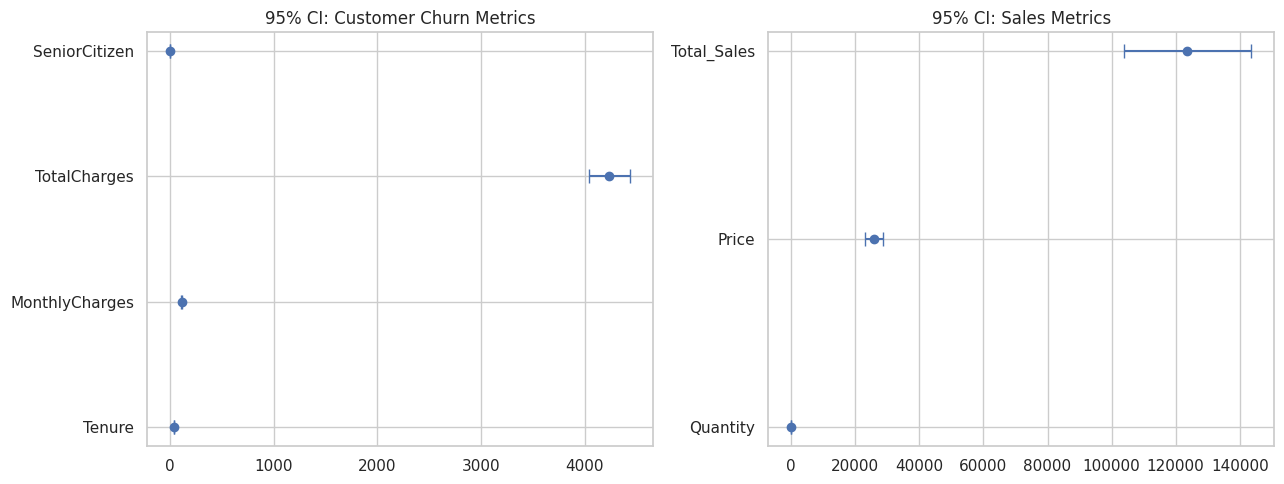

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, table, title in [(axes[0], churn_ci, "Customer Churn Metrics"), (axes[1], sales_ci, "Sales Metrics")]:
    y_pos = np.arange(len(table))
    ax.errorbar(table["mean"], y_pos, xerr=table["margin_of_error"], fmt="o", capsize=5, color="#4C72B0")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(table.index)
    ax.set_title(f"95% CI: {title}")
plt.tight_layout()
plt.show()

In [23]:
# Confidence interval for the DIFFERENCE in means between two groups
def ci_difference_of_means(dataframe, metric, group_col, group1, group2, confidence=0.95):
    g1 = dataframe.loc[dataframe[group_col] == group1, metric].dropna()
    g2 = dataframe.loc[dataframe[group_col] == group2, metric].dropna()
    diff = g1.mean() - g2.mean()
    se_diff = np.sqrt(g1.var(ddof=1) / len(g1) + g2.var(ddof=1) / len(g2))
    dof = len(g1) + len(g2) - 2
    margin = se_diff * stats.t.ppf((1 + confidence) / 2, df=dof)
    return diff, diff - margin, diff + margin

diff, lower, upper = ci_difference_of_means(churn, "MonthlyCharges", "ChurnLabel", "Churned", "Retained")
print(f"Monthly Charges difference (Churned - Retained): {diff:.2f}")
print(f"95% CI: [{lower:.2f}, {upper:.2f}]")
print("-> If this interval excludes 0, the difference is significant at the 95% level.")

Monthly Charges difference (Churned - Retained): 18.05
95% CI: [4.65, 31.45]
-> If this interval excludes 0, the difference is significant at the 95% level.


## Summary

- Section 2 gives a full statistical profile of both datasets.
- Section 3 shows whether metrics are normally distributed, skewed, or have outliers — this determines which tests are valid.
- Section 4 tests whether Monthly Charges/Tenure genuinely differ between churned and retained customers, and whether the top two regions' sales differ.
- Section 5 quantifies relationships between metrics (e.g. tenure vs. total charges).
- Section 6 translates p-values into plain-language business recommendations.
- Section 7 gives the uncertainty range around every key estimate, including the churn rate itself.

To reuse this notebook on new data: keep the same column names, or update the column-name variables (`churn_numeric`, `sales_numeric`, group columns) at the top of each section.